In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpdaf.obj import Cube
from astropy.coordinates import SkyCoord
import sys
import os
import plotfancy as pf
from matplotlib.patches import Circle, Rectangle, ConnectionPatch
from astropy.visualization import ZScaleInterval
from matplotlib.ticker import FuncFormatter
from astropy.table import Table
from types import SimpleNamespace
import re
from astropy.io import ascii, fits
from astropy.wcs import WCS
from astropy import units as u
from astropy.table import Table, vstack, hstack
from scipy.optimize import curve_fit
from astropy.cosmology import WMAP9 as cosmo
from astropy import coordinates as coords
from astroquery.sdss import SDSS
from requests.exceptions import ConnectionError
from matplotlib.lines import Line2D
from astropy.visualization import make_lupton_rgb, AsinhStretch, ImageNormalize, simple_norm
from crop import crop
from astropy.wcs.utils import skycoord_to_pixel, proj_plane_pixel_scales
# from hst_phot import *
import matplotlib.patches as patches
from astropy.table import vstack
from reproject import reproject_interp

# from calculate_jiang19_metallicity import calculate_metallicity_jiang19 as cjm19
sys.path.append('../../../../')
import src.ifu_tools.line_ratios as lr
import src.ifu_tools.ifutools as ift
from src.ifu_tools.run_photometry import download_hst_image, download_spitzer_image, BANDS
import logging 
logging.getLogger('mpdaf').setLevel(logging.WARNING)
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

pf.housestyle_rcparams()
lines_of_interest = {
'oiii5007': 5006.84,
'oiii4959': 4958.91,
'oii3726':  3726.03,
'halpha':   6562.80,
'hbeta':    4861.33,
'hgamma':   4340.46,
}
rest_lambdas = {
# --- Primary [OIII] and [OII] ---
'oiii5007': 5006.84,
'oiii4959': 4958.91,
'oii3726':  3726.03,
'oii3729':  3728.82,

# --- Hydrogen Balmer Series ---
'halpha':   6562.80,
'hbeta':    4861.33,
'hgamma':   4340.46,
'hdelta':   4101.73,
'hepsilon': 3970.08,
'hzeta':    3889.06,
'heta':     3835.40,

# --- Key Diagnostic Lines ---
'oiii4363': 4363.21,
'neiii':    3868.75,

# --- Low-Ionization Lines ---
'nii6583':  6583.45,
'nii6548':  6548.05,
'sii6716':  6716.44,
'sii6731':  6730.82,

# --- Helium Lines ---
'heii4686': 4685.68,
'hei5876':  5875.62,
}
balmer_lambda = {
# 'halpha':   6562.80,
'hbeta':    4861.33,
'hgamma':   4340.46,
'hdelta':   4101.73,
'hepsilon': 3970.08,
'hzeta':    3889.06,
'heta':     3835.40,
}
lambda_keys = {
# --- Primary [OIII] and [OII] ---
'oiii5007': r'[OIII] $\lambda$5007',
'oiii4959': r'[OIII] $\lambda$4959',
'oii3726':  r'[OII] $\lambda$3726',
'oii3729':  r'[OII] $\lambda$3729',

# --- Hydrogen Balmer Series ---
'halpha':   r'H$\alpha$',
'hbeta':    r'H$\beta$',
'hgamma':   r'H$\gamma$',
'hdelta':   r'H$\delta$',
'hepsilon': r'H$\epsilon$',
'hzeta':    r'H$\zeta$',
'heta':     r'H$\eta$',

# --- Key Diagnostic Lines ---
'oiii4363': r'[OIII] $\lambda$4363',  # Auroral line
'neiii':    r'[NeIII] $\lambda$3869',

# --- Low-Ionization Lines ---
'nii6583':  r'[NII] $\lambda$6583',
'nii6548':  r'[NII] $\lambda$6548',
'sii6716':  r'[SII] $\lambda$6716',
'sii6731':  r'[SII] $\lambda$6731',

# --- Helium Lines (not forbidden) ---
'heii4686': r'HeII $\lambda$4686',
'hei5876':  r'HeI $\lambda$5876',
}

test = ascii.read('../../catalogue_analysis/allsources.csv')
tab = test[test['object_id']!= 'STACK']
SNR_mask = ((tab['oiii5007_flux']/tab['oiii5007_flux_err'])>5)&((tab['oiii4959_flux']/tab['oiii4959_flux_err'])>5)
EW_mask = (tab['oiii5007_ew']>100)|(tab['hbeta_ew']>50)
selection = tab[SNR_mask&EW_mask]
tab.sort('oiii5007_ew')

In [18]:
cand = selection[selection['object_id']=='8d28m41pt88s-7d51m59pt549s']
galloc = SkyCoord(cand['ra'][0], cand['dec'][0], unit=u.deg)
print(cand['name'])
print(galloc)
gloc, cift, clust, speco, specr = ift.get_fromIFU(cand[0],locpref='../../../../cubes/')

    name   
-----------
macs0033m07
<SkyCoord (ICRS): (ra, dec) in deg
    (8.4783, -7.86654139)>
macs0033m07


In [17]:
# for band_name, band_info in BANDS.items():
#     query_name, instrument, archive = band_info
#     image_path = None
#     if archive == 'MAST':
#         image_path = download_hst_image(galloc, (query_name, instrument), 'plot')
#     elif archive == 'Spitzer':
#         image_path = download_spitzer_image(galloc, (query_name, instrument), 'plot')

In [4]:
with fits.open('plot/mastDownload/HST/jbtab0010/jbtab0010_drc.fits') as hdul_b:
    image_b = hdul_b[1].data
    header_b = hdul_b[1].header
    wcs_b = WCS(header_b)
with fits.open('plot/mastDownload/HST/jbtaa3010/jbtaa3010_drc.fits') as hdul_g:
    image_g = hdul_g[1].data
    header_g = hdul_g[1].header
with  fits.open('plot/mastDownload/HST/jbtaa3020/jbtaa3020_drc.fits') as hdul_r:
    image_r = hdul_r[1].data
    header_r = hdul_r[1].header
    wcs_r = WCS(header_r)
with  fits.open('plot/spitzer_IRAC_2.fits') as spitzer:
    image_s = spitzer[0].data
    header_s = spitzer[0].header
    wcs_s = WCS(header_s)


image_b_reprojected, footprint_b = reproject_interp((image_b, wcs_b),header_g)
image_r_reprojected, footprint_r = reproject_interp((image_r, wcs_r),header_g)
# image_rgb = make_lupton_rgb(image_r, image_g, image_b)

In [5]:
rgb_image = make_lupton_rgb(
image_r_reprojected,
image_g,
image_b_reprojected,
stretch=0.5,
Q=8
)

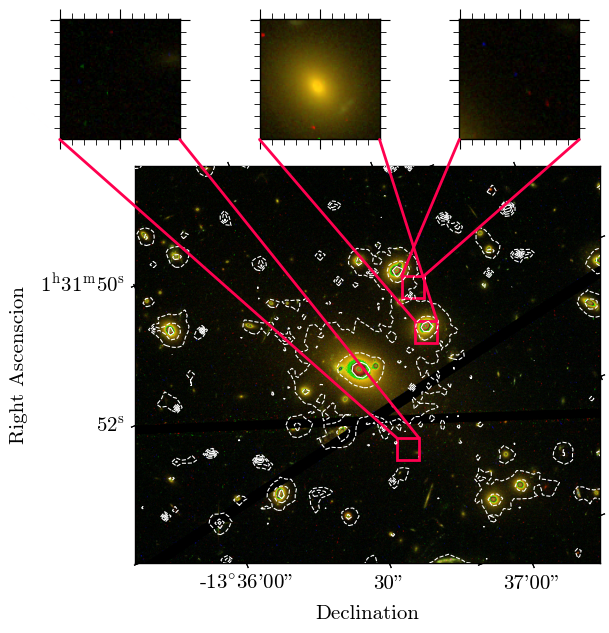

In [10]:
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(1, 1, 1, projection=wcs_r)

center_coord = SkyCoord(ra=22.9689655*u.deg, dec=-13.6112060*u.deg, frame='icrs')
plot_radius = 1 * u.arcmin

# 2. Calculate the RA and Dec limits for the plot
#    The plot will be a square with width and height of 2 * plot_radius
ra_lim = (center_coord.ra - plot_radius, center_coord.ra + plot_radius)
dec_lim = (center_coord.dec - plot_radius, center_coord.dec + plot_radius)
ax.imshow(rgb_image*3, zorder=-1)
# ax.imshow(image_s, transform=ax.get_transform(wcs_s), alpha=.1)
# ax.coords[0].set_lim(ra_lim)
# ax.set_ylim(ra_lim[0].value, ra_lim[1].value, transform='icrs')
points = []
for i in [0,1]:
    for j in [0,1]:
        skoord = SkyCoord(ra_lim[i], dec_lim[j])
        x,y = wcs_r.world_to_pixel(skoord)
        points.append([x,y])
points = np.array(points)

y,x = wcs_r.world_to_pixel(center_coord)
# ax.scatter([y],[x])

# ax.imshow(image_s.T,transform=ax.get_transform(wcs_s), vmax=.2, vmin=0.01, alpha=0.1, cmap='magma')
ax.contour(np.log10(image_s), transform=ax.get_transform(wcs_s), colors='white', levels=10, linewidths=0.8)

ax.set_ylabel('Right Ascenscion')
ax.set_xlabel('Declination')
ax.set_xlim(1100,3200)
ax.set_ylim(1510,3300)

ax.get_ylim()

photaxes = []
a209 = tab[(tab['object_id']!='22d57m55pt32s-13d37m11pt705s')&(tab['name']=='a209')]
for i in range(3):
    pea = a209[-i]

    peacoord = SkyCoord(pea['ra'], pea['dec'], unit=u.deg)
    x,y = wcs_r.world_to_pixel(peacoord)

    # ax.scatter([y],[x], s=100,)

    photax = fig.add_axes((i*0.333, 0.87, 0.2,0.2))
    photaxes.append(photax)
    # photax.set_xticks([])
    # photax.set_yticks([])
    plt.setp(photax.get_xticklabels(), visible=False)
    plt.setp(photax.get_yticklabels(), visible=False)
    x = int(x)
    y = int(y)

    if i == 1:
        j=20

    photax.imshow(rgb_image[x-50+j:x+50+j, y-50:y+50,:])

    rect = Rectangle((y-50, x-50), 100, 100, fill=False, edgecolor='#ff004f', lw=2, ls='-')
    ax.add_patch(rect)

    con1 = ConnectionPatch(xyA=(y-50, x+50), xyB=(0, 0), coordsA='data', coordsB='axes fraction',
                           axesA=ax, axesB=photax, color='#ff004f', lw=2, ls='-')

    con2 = ConnectionPatch(xyA=(y+50, x+50), xyB=(1, 0), coordsA='data', coordsB='axes fraction',
                           axesA=ax, axesB=photax, color='#ff004f', lw=2, ls='-')

    # Add the connector lines to the figure
    fig.add_artist(con1)
    fig.add_artist(con2)

ax.coords[1].set_separator((r'$^{\circ}$', "'", '"'))

pf.fix_plot(photaxes, tickdir='out')
fig.savefig(f'figs/a209_viaHST.png', dpi=600, bbox_inches='tight')

In [7]:
np.array(points)

array([[2798.28541585, 3904.33815261],
       [ 573.0326777 , 3005.31021022],
       [3672.15055275, 1741.79388755],
       [1447.02097999,  842.46135001]])

In [8]:
plt.hist(np.(image_s.flatten()), bins=np.linspace(0,10))

SyntaxError: invalid syntax (2393289103.py, line 1)

In [ ]:
np.nanmean(image_s.flatten())

np.float32(0.13143064)

In [ ]:
a209

object_id,ra,dec,z,angdisp,foreground,cluster_member,lensed,Z_dir,Z_dir_e,Z_j19,Z_j19_e,R23,R23_e,mean_vel_disp,sterr_vel_disp,zcluster,name,oiii5007_flux,oiii5007_flux_err,oiii5007_ew,oiii5007_ew_err,oiii5007_centroid,oiii5007_fwhm,oiii5007_vel_disp,oiii4959_flux,oiii4959_flux_err,oiii4959_ew,oiii4959_ew_err,oiii4959_centroid,oiii4959_fwhm,oiii4959_vel_disp,oii3726_flux,oii3726_flux_err,oii3726_ew,oii3726_ew_err,oii3726_centroid,oii3726_fwhm,oii3726_vel_disp,oii3729_flux,oii3729_flux_err,oii3729_ew,oii3729_ew_err,oii3729_centroid,oii3729_fwhm,oii3729_vel_disp,halpha_flux,halpha_flux_err,halpha_ew,halpha_ew_err,halpha_centroid,halpha_fwhm,halpha_vel_disp,hbeta_flux,hbeta_flux_err,hbeta_ew,hbeta_ew_err,hbeta_centroid,hbeta_fwhm,hbeta_vel_disp,hgamma_flux,hgamma_flux_err,hgamma_ew,hgamma_ew_err,hgamma_centroid,hgamma_fwhm,hgamma_vel_disp,hdelta_flux,hdelta_flux_err,hdelta_ew,hdelta_ew_err,hdelta_centroid,hdelta_fwhm,hdelta_vel_disp,hepsilon_flux,hepsilon_flux_err,hepsilon_ew,hepsilon_ew_err,hepsilon_centroid,hepsilon_fwhm,hepsilon_vel_disp,hzeta_flux,hzeta_flux_err,hzeta_ew,hzeta_ew_err,hzeta_centroid,hzeta_fwhm,hzeta_vel_disp,heta_flux,heta_flux_err,heta_ew,heta_ew_err,heta_centroid,heta_fwhm,heta_vel_disp,oiii4363_flux,oiii4363_flux_err,oiii4363_ew,oiii4363_ew_err,oiii4363_centroid,oiii4363_fwhm,oiii4363_vel_disp,neiii_flux,neiii_flux_err,neiii_ew,neiii_ew_err,neiii_centroid,neiii_fwhm,neiii_vel_disp,nii6583_flux,nii6583_flux_err,nii6583_ew,nii6583_ew_err,nii6583_centroid,nii6583_fwhm,nii6583_vel_disp,nii6548_flux,nii6548_flux_err,nii6548_ew,nii6548_ew_err,nii6548_centroid,nii6548_fwhm,nii6548_vel_disp,sii6716_flux,sii6716_flux_err,sii6716_ew,sii6716_ew_err,sii6716_centroid,sii6716_fwhm,sii6716_vel_disp,sii6731_flux,sii6731_flux_err,sii6731_ew,sii6731_ew_err,sii6731_centroid,sii6731_fwhm,sii6731_vel_disp,heii4686_flux,heii4686_flux_err,heii4686_ew,heii4686_ew_err,heii4686_centroid,heii4686_fwhm,heii4686_vel_disp,hei5876_flux,hei5876_flux_err,hei5876_ew,hei5876_ew_err,hei5876_centroid,hei5876_fwhm,hei5876_vel_disp
str29,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str12,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
22d58m08pt31s-13d36m35pt054s,22.968974999999997,-13.609737222222222,0.4161413873607225,22.67086897038117,0,0,0,9.685796779483624,0.034594006475257885,8.21395013660419,0.0012164515694572861,nan,nan,61.45215842275653,13.24433227452109,0.206,a209,4405.66930000519,100.19228510410649,9.477621169998068,0.5887192194355708,5006.841550725798,1.7628687522055395,41.13956731048468,1109.0472586020212,189.03136101902393,2.069479622464781,0.9786437720077968,4959.0335869350565,1.4806841416910674,33.4973779971686,462.82999435928826,202.15422535776156,0.8076710352921309,1.7782597253076347,3725.052455019966,1.6124316682534134,49.630798309450164,1506.3675080327457,525.1616468648513,2.6352185206091048,4.619610617800723,3728.58973669571,1.6124316682534134,49.593663

In [ ]:
header_r

XTENSION= 'IMAGE   '           / Image extension                                
BITPIX  =                  -32 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                 4241                                                  
NAXIS2  =                 4253                                                  
PCOUNT  =                    0 / number of parameters                           
GCOUNT  =                    1 / number of groups                               
INHERIT =                    T / inherit the primary header                     
EXTNAME = 'SCI     '           / extension name                                 
EXTVER  =                    1                                                  
BUNIT   = 'ELECTRONS/S'        / Units of science product                       
                                                                                
CD1_1   = 5.20376187099976E-

In [ ]:
header_g

XTENSION= 'IMAGE   '           / Image extension                                
BITPIX  =                  -32 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                 4219                                                  
NAXIS2  =                 4255                                                  
PCOUNT  =                    0 / number of parameters                           
GCOUNT  =                    1 / number of groups                               
INHERIT =                    T / inherit the primary header                     
EXTNAME = 'SCI     '           / extension name                                 
EXTVER  =                    1                                                  
BUNIT   = 'ELECTRONS/S'        / Units of science product                       
                                                                                
CD1_1   = 5.20376201922953E-